# 04 — AN 7.1–7.3용 background estimation 자료

현재 AN_23_107의 **7.1 Background composition → 7.2 Estimation method → 7.3 Validation**을 채우는 최소 그림·표를 만든다.
현재 AN PDF p.40(인쇄 p.38)의 7장은 제목만 있고, MC 통계 한계는 8.9에 별도로 설명돼 있다.
이전 AN2018_125의 Fig.28·Table20·Tables23–24 형식은 참고하되 물리 정의와 결론은 현재 결과로 교체한다.

- mass inclusive, |Δφ|≥2의 **비교 스터디**이며 최종 selection/WP 검증이 아니다.
- 현재는 iso–iso, displacement 반전 VR, signal quadrant A이다.
- 이전 iso–Δφ, proxy μ/b-tag VR, signal quadrant D의 수식·검증 결론을 가져오지 않는다.
- MC 배경만 다시 읽는다. DATA는 01·02의 **이미 저장된 수치표**에서 가져오며 원본 DATA 파일을 읽지 않는다.
- DATA 표는 과거 대표 두 신호 gate로 생성한 **조건부 진단**이다. 03의 정규화·보호 SR·공개 기준 합의가 완료됐다는 의미가 아니다.
- DATA의 관측 A/BC/D 수율은 저장 수치표에 없어 재구성하지 않는다. 여기서는 κ 그림과 요약표를 사용한다.

기본 출력은 composition 1장, region 정의 1장, 채널별 DATA κ 그림 2장, 간결한 정의·수율·κ 표이다.
상세 correlation·신호 가설 스캔은 01–03에 둔다.


In [1]:
from pathlib import Path
from dataclasses import dataclass
import gc
import sys
import json
from datetime import datetime, timezone

SIDM_DIR = next((p for p in (Path.cwd(), *Path.cwd().parents) if p.name == "sidm"), None)
if SIDM_DIR is None:
    raise RuntimeError("sidm 저장소 안에서 실행하세요.")
if str(SIDM_DIR.parent) not in sys.path:
    sys.path.insert(0, str(SIDM_DIR.parent))
import coffea.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
from matplotlib.patches import Rectangle
from IPython.display import display

if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.multiarray as _numpy_multiarray
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.multiarray", _numpy_multiarray)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)
plt.rcParams.update({"figure.dpi": 100, "font.size": 10, "axes.spines.top": True,
                     "axes.spines.right": True, "pdf.fonttype": 42})
pd.set_option("display.max_columns", 18)
import ast
import hashlib
from html.parser import HTMLParser
import nbformat
from matplotlib.ticker import PercentFormatter


## 설정

대표 composition은 loose (0.5,0.5)의 **A 영역**에서 SR/VR의 배경 성분을 비교한다.
COMPOSITION_REGION을 B/C/D 또는 All로 바꾸면 다른 영역을 확인할 수 있다.
All은 두 iso 축의 모든 pass/fail을 합친 것으로, iso<0.5 preselection을 뜻하지 않는다.

본문 DATA scan은 두 방향 모두 동일한 표시 범위 0–1을 기본으로 한다. 결과의 closure 여부로 지점을 고르지 않는다.
전체 0.05–5 수치는 CSV에 남기며 AN_SCAN_MAX=None으로 전체를 표시할 수 있다.
4μ κ는 오차 양 끝까지 자동 범위로 표시한다.

SAVE_OUTPUTS=True이면 실행 시각별 새 폴더에 PDF·PNG·CSV·LaTeX 표를 저장한다.
PDF를 읽는 추가 패키지는 노트북 실행에 필요 없다.


In [2]:
CAMPAIGN = "ABCD_6D_inclusive_eHEM_skimv1_v1"
INPUT_BASE = SIDM_DIR / "studies/ABCD_plane_summary"
VARS = ("iso0", "iso1", "disp0", "disp1", "abs_dphi", "ljlj_mass")
EDGES = {
    "iso": np.array([0, .05, .1, .15, .2, .25, .3, .4, .5, .75, 1, 2, 5]),
    "pixel": np.arange(-.5, 12, 1, dtype=float),
    "lost": np.arange(-.5, 10, 1, dtype=float),
    "abs_dphi": np.array([0, .5, 1, 1.5, 2, 2.2, 2.4, 2.6, 2.7, 2.8, 2.9, 3, 3.05, 3.1, np.pi]),
    "ljlj_mass": np.array([0, 50, 100, 150, 200, 300, 400, 600, 800, 1000, 1500, 2500], float),
}
ISO_CUTS = EDGES["iso"][1:]
MIN_NEFF = 10.
CHANNELS = {"2mu2e": (2,), "4mu": (2, 3)}
COMPARISON_WPS = ((.25, .25), (.5, .5))
COMPOSITION_WP = (.5, .5)
COMPOSITION_REGION = "A"
AN_SCAN_MAX = 1.0
SAVE_OUTPUTS = True
OUTPUT_ROOT = INPUT_BASE / "04_AN_background_estimation_outputs"
RUN_DIR = OUTPUT_ROOT / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
SOURCE_NOTEBOOKS = {
    "2mu2e": INPUT_BASE / "01_Iso_iso_2mu2e_summary.ipynb",
    "4mu": INPUT_BASE / "02_Iso_iso_4mu_summary.ipynb",
}
SOURCE_PDFS = (
    INPUT_BASE / "AN_23_107__SIDM_10.06.pdf",
    INPUT_BASE / "SIDM AN2018_125_v4 (Search for Self-Interacting Dark Matter in Events with Two Lepton-Jets).pdf",
)
BACKGROUND_GROUPS = ("QCD", "DY", "TTJets", "Diboson")
BACKGROUND_COLORS = {"QCD": "#832db6", "DY": "#b9ac70", "TTJets": "#3f90da", "Diboson": "#717581"}
GROUP_LABELS = {"QCD": "QCD", "DY": "DY", "TTJets": r"$t\bar{t}$", "Diboson": "Diboson"}
FIGURE_CAPTIONS = {}
SOURCE_RECORDS = []


## 계산·출력 helper

01–03과 동일한 bin edge·flow·projection·sumw2 규약을 사용한다.
저장된 weighted sumw/sumw2를 그대로 사용하며 luminosity·cross section을 다시 곱하지 않는다.
저장 HTML 표는 표준 Python parser로 읽으며, 지점 수·중복·gate·κ 오차를 확인한다.
저장된 DATA 수치는 notebook에 출력된 정밀도이며 원래 커널 배열의 전체 정밀도는 아니다.


In [3]:
@dataclass
class Plane:
    """Flow bin을 포함한 iso–iso sumw, sumw2와 두 축의 edge."""
    w: np.ndarray
    v: np.ndarray
    ex: np.ndarray
    ey: np.ndarray


def _axis_edges(variable):
    if variable in ("iso0", "iso1"):
        return EDGES["iso"]
    if variable in ("disp0", "disp1"):
        return EDGES["lost" if TOPOLOGY == "2mu2e" and variable == "disp1" else "pixel"]
    return EDGES[variable]


def _split(edges, threshold):
    locations = np.flatnonzero(np.isclose(edges, float(threshold), rtol=0, atol=1e-12))
    if len(locations) != 1:
        raise ValueError(f"저장된 bin edge가 아닌 경계: {threshold}")
    return int(locations[0]) + 1


def make_profiles():
    return [dict(profile=f"pixel{pixel:g}", mass_min=None, dphi_min=2., pixel_max=float(pixel))
            for pixel in PIXEL_WPS]


def _source_paths(source):
    directory = INPUT_BASE / f"{CAMPAIGN}_{source}_merged_samples_v1"
    paths = sorted(directory.glob("*.coffea"))
    expected = {"bkg": 18, "data": 68, "signal": 180}[source]
    if len(paths) != expected or any(path.stat().st_size <= 0 for path in paths):
        raise RuntimeError(f"입력 파일 수/크기 불일치: {source}; {len(paths)}/{expected}; {directory}")
    return paths


def _background_group(sample):
    if sample.startswith("QCD_"):
        return "QCD"
    if sample.startswith("DYJetsTo"):
        return "DY"
    if sample == "TTJets":
        return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}:
        return "Diboson"
    raise ValueError(f"분류되지 않은 배경: {sample}")


def _load_cube(path, source):
    """배경 MC schema를 검사한다. 수치 검사는 실제 선택한 slice에 적용한다."""
    if source != "bkg":
        raise ValueError("04에서는 원본 배경 MC만 읽습니다.")
    payload = coffea.util.load(path)
    if not isinstance(payload, dict) or set(payload.get("out", {})) != {path.stem}:
        raise ValueError(f"sample identity 불일치: {path}")
    out = payload["out"][path.stem]
    expected = {f"abcd6d_{t}" for t in ("2mu2e", "4mu")} | {
        f"abcd6d_ref_{t}_{pair}" for t in ("2mu2e", "4mu")
        for pair in ("iso0_vs_iso1", "iso0_vs_abs_dphi", "disp0_vs_disp1")}
    if set(out["hists"]) != expected:
        raise ValueError(f"6D campaign histogram key 불일치: {path}")
    metadata = out["metadata"]
    if set(metadata["is_data"]) != {source == "data"}:
        raise ValueError(f"is_data metadata 불일치: {path}")
    if set(metadata["unweighted_hist"]) != {False}:
        raise ValueError(f"weighted histogram이 필요합니다: {path}")
    if {str(value) for value in metadata["year"]} != {"2018"}:
        raise ValueError(f"year metadata 불일치: {path}")
    if any(h.storage_type.__name__ != "Weight" for h in out["hists"].values()):
        raise ValueError(f"Weight storage 불일치: {path}")
    histogram = out["hists"][f"abcd6d_{TOPOLOGY}"]
    if tuple(a.name for a in histogram.axes) != ("channel",) + tuple(VARS):
        raise ValueError(f"6D 축 순서 불일치: {path}")
    axis = histogram.axes["channel"]
    channel = f"abcd6d_inclusive_{TOPOLOGY}_dxySpread_cosAlpha_mu_veto_eHEM"
    if (not axis.traits.discrete or axis.traits.underflow or axis.traits.overflow
            or list(axis) != [channel]):
        raise ValueError(f"topology channel 불일치: {path}")
    for variable in VARS:
        axis, edges = histogram.axes[variable], _axis_edges(variable)
        if not (axis.traits.underflow and axis.traits.overflow):
            raise ValueError(f"flow bin 누락: {path}/{variable}")
        if np.shape(axis.edges) != np.shape(edges) or not np.allclose(
                axis.edges, edges, rtol=0, atol=1e-12):
            raise ValueError(f"frozen bin edge 불일치: {path}/{variable}")
    values, variances = histogram.values(flow=True), histogram.variances(flow=True)
    shape = (1,) + tuple(len(_axis_edges(variable)) + 1 for variable in VARS)
    if variances is None or values.shape != shape or variances.shape != shape:
        raise ValueError(f"sumw2/shape 불일치: {path}")
    # ndarray view가 histogram storage를 소유하므로 다른 topology payload를 해제할 수 있다.
    return values[0], variances[0]


def _validate_storage(weights, variances):
    if not np.isfinite(weights).all() or not np.isfinite(variances).all():
        raise ValueError("선택한 histogram에 finite가 아닌 값이 있습니다.")
    if np.any(variances < 0):
        raise ValueError("선택한 histogram에 음수 sumw2가 있습니다.")


def _projection(weights, variances, profile, context):
    if context not in {"SR", "VR"}:
        raise ValueError(context)
    pixel_edge = profile["pixel_max"] + .5
    pixel_split = _split(_axis_edges("disp0"), pixel_edge)
    if TOPOLOGY == "2mu2e":
        second_split = _split(_axis_edges("disp1"), .5)  # lost hits >= 1
        second = slice(second_split, None) if context == "SR" else slice(None, second_split)
    else:
        second_split = _split(_axis_edges("disp1"), pixel_edge)
        second = slice(None, second_split) if context == "SR" else slice(second_split, None)
    first = slice(None, pixel_split) if context == "SR" else slice(pixel_split, None)
    dphi = slice(_split(_axis_edges("abs_dphi"), profile["dphi_min"]), None)
    mass = (slice(None) if profile["mass_min"] is None else
            slice(_split(_axis_edges("ljlj_mass"), profile["mass_min"]), None))
    selected = (slice(None), slice(None), first, second, dphi, mass)
    w, v = weights[selected], variances[selected]
    _validate_storage(w, v)
    # SR과 VR은 각각 두 displacement 조건을 AND로 묶는다.
    return Plane(w.sum(axis=(2, 3, 4, 5)), v.sum(axis=(2, 3, 4, 5)),
                 np.asarray(EDGES["iso"]), np.asarray(EDGES["iso"]))


def _add_plane(planes, key, plane):
    if key not in planes:
        planes[key] = Plane(plane.w.copy(), plane.v.copy(), plane.ex.copy(), plane.ey.copy())
    else:
        target = planes[key]
        if not np.array_equal(target.ex, plane.ex) or not np.array_equal(target.ey, plane.ey):
            raise ValueError("합산 plane의 binning이 다릅니다.")
        target.w += plane.w
        target.v += plane.v


def _quadrants(plane, tx, ty):
    ix, iy = _split(plane.ex, tx), _split(plane.ey, ty)
    slices = {"A": (slice(None, ix), slice(None, iy)),
              "B": (slice(ix, None), slice(None, iy)),
              "C": (slice(None, ix), slice(iy, None)),
              "D": (slice(ix, None), slice(iy, None))}
    _validate_storage(plane.w, plane.v)
    result = {}
    for region, index in slices.items():
        value, variance = float(plane.w[index].sum()), float(plane.v[index].sum())
        neff = value**2 / variance if variance > 0 else 0. if value == 0 else np.nan
        result[region] = dict(value=value, variance=variance, neff=neff)
    return result


def _empty_metrics(tx, ty, status):
    result = dict(threshold_x=float(tx), threshold_y=float(ty), pred=np.nan,
                  pred_error=np.nan, kappa=np.nan, kappa_error=np.nan, pull=np.nan,
                  min_neff=np.nan, min_sideband_neff=np.nan, low_stat=np.nan,
                  status=status, kappa_status=status)
    for region in "ABCD":
        result.update({region: np.nan, "var_" + region: np.nan,
                       "neff_" + region: np.nan, region + "_error": np.nan})
    return result


def metrics(plane, tx, ty):
    stats = _quadrants(plane, tx, ty)
    result = _empty_metrics(tx, ty, "EMPTY_OR_NONPOSITIVE_SIDEBAND")
    for region, item in stats.items():
        result.update({region: item["value"], "var_" + region: item["variance"],
                       "neff_" + region: item["neff"], region + "_error": np.sqrt(item["variance"])})
    neffs = np.array([stats[r]["neff"] for r in "ABCD"])
    result.update(min_neff=float(np.min(neffs)), min_sideband_neff=float(np.min(neffs[1:])),
                  low_stat=bool(not np.all(np.isfinite(neffs) & (neffs >= MIN_NEFF))))
    a, b, c, d = (stats[r]["value"] for r in "ABCD")
    va, vb, vc, vd = (stats[r]["variance"] for r in "ABCD")
    if not all(np.isfinite(value) and value > 0 for value in (b, c, d)):
        return result
    pred = b * c / d
    vp = (c / d)**2 * vb + (b / d)**2 * vc + (b * c / d**2)**2 * vd
    if not np.isfinite(pred) or pred <= 0 or not np.isfinite(vp):
        result.update(status="UNDEFINED_PREDICTION", kappa_status="UNDEFINED_PREDICTION")
        return result
    result.update(pred=pred, pred_error=np.sqrt(vp),
                  status="OK" if np.all(np.isfinite(neffs[1:]) & (neffs[1:] >= MIN_NEFF))
                  else "LOW_STAT_SIDEBAND")
    if a <= 0:
        result["kappa_status"] = "EMPTY_OR_NONPOSITIVE_A"
        return result
    kappa_variance = va / pred**2 + a**2 * vp / pred**4
    result.update(kappa=a / pred, kappa_error=np.sqrt(kappa_variance),
                  kappa_status="LOW_STAT" if result["low_stat"] else "OK",
                  pull=(a - pred) / np.sqrt(va + vp) if va + vp > 0 else np.nan)
    return result

In [4]:
class SavedTableParser(HTMLParser):
    def __init__(self):
        super().__init__(convert_charrefs=True)
        self.rows, self.row, self.parts = [], None, None

    def handle_starttag(self, tag, attrs):
        if tag == "tr":
            self.row = []
        elif tag in {"th", "td"}:
            self.parts = []

    def handle_data(self, data):
        if self.parts is not None:
            self.parts.append(data)

    def handle_endtag(self, tag):
        if tag in {"th", "td"} and self.parts is not None:
            self.row.append("".join(self.parts).strip())
            self.parts = None
        elif tag == "tr" and self.row is not None:
            self.rows.append(self.row)
            self.row = None


def record_source(path, kind):
    SOURCE_RECORDS.append(dict(kind=kind, path=str(path), bytes=path.stat().st_size,
                              sha256=hashlib.sha256(path.read_bytes()).hexdigest()))


def saved_table(notebook, marker, required):
    candidates = []
    for cell_index, cell in enumerate(notebook.cells):
        if cell.cell_type != "code" or marker not in cell.source:
            continue
        for output in cell.get("outputs", []):
            raw = output.get("data", {}).get("text/html")
            if not raw:
                continue
            parser = SavedTableParser()
            parser.feed(raw if isinstance(raw, str) else "".join(raw))
            if not parser.rows or not set(required) <= set(parser.rows[0]):
                continue
            header, rows = parser.rows[0], parser.rows[1:]
            if any(len(row) != len(header) or "..." in row for row in rows):
                raise ValueError("저장된 표가 생략되어 있습니다. 01/02에서 전체 표를 다시 출력하세요.")
            frame = pd.DataFrame(rows, columns=header)
            frame = frame.drop(columns=[""], errors="ignore")
            frame["source_cell"] = cell_index
            frame["source_execution_count"] = cell.get("execution_count")
            candidates.append(frame)
    if not candidates:
        raise ValueError(f"저장된 수치표가 없습니다: {marker}")
    first = candidates[0]
    for other in candidates[1:]:
        pd.testing.assert_frame_equal(first, other)
    return first


def read_saved_data():
    scans, points = [], []
    for channel, path in SOURCE_NOTEBOOKS.items():
        notebook = nbformat.read(path, as_version=4)
        record_source(path, "saved_notebook_output")
        for marker, target, expected in (
            ("one_d_scan = ", scans, len(CHANNELS[channel])*(2*len(ISO_CUTS)-1)),
            ("comparison_points = ", points, len(CHANNELS[channel])*len(COMPARISON_WPS))):
            frame = saved_table(notebook, marker,
                ["profile", "tx", "ty", "gate_passed", "data_VR_kappa", "data_VR_kappa_error"])
            if len(frame) != expected or frame.duplicated(["profile", "tx", "ty"]).any():
                raise ValueError(f"저장 지점 수/중복 불일치: {path.name}/{marker}")
            expected_profiles = {f"pixel{k:g}" for k in CHANNELS[channel]}
            if set(frame.profile) != expected_profiles:
                raise ValueError("저장 profile과 04 설정이 다릅니다.")
            for column in frame:
                if column in {"tx", "ty"} or column.startswith(("mc_", "data_")):
                    frame[column] = pd.to_numeric(frame[column].replace({"NaN": np.nan, "nan": np.nan}))
            if not frame.gate_passed.isin(["True", "False"]).all():
                raise ValueError("gate_passed boolean 형식 불일치")
            frame["legacy_gate_passed"] = frame.pop("gate_passed").map({"True": True, "False": False})
            frame.loc[~frame.legacy_gate_passed, ["data_VR_kappa", "data_VR_kappa_error"]] = np.nan
            if (frame.data_VR_kappa_error.dropna() < 0).any():
                raise ValueError("음수 DATA κ 오차")
            for p in expected_profiles:
                rows = frame.loc[frame.profile.eq(p)]
                actual = {(float(x), float(y)) for x, y in zip(rows.tx, rows.ty)}
                expected_points = (set(COMPARISON_WPS) if target is points else
                    {(float(x), .5) for x in ISO_CUTS} | {(.5, float(y)) for y in ISO_CUTS})
                if actual != expected_points:
                    raise ValueError(f"저장 WP 집합 불일치: {channel}/{p}")
            frame.insert(0, "channel", channel)
            frame["source_notebook"] = path.name
            frame["data_status"] = "conditional diagnostic; legacy gate"
            target.append(frame)
    scan = pd.concat(scans, ignore_index=True)
    refs = pd.concat(points, ignore_index=True)
    shared = scan.merge(refs, on=["channel", "profile", "tx", "ty"], suffixes=("_scan", "_ref"))
    for metric in ("data_VR_kappa", "data_VR_kappa_error"):
        np.testing.assert_allclose(shared[metric+"_scan"], shared[metric+"_ref"], equal_nan=True, atol=1e-6)
    return scan, refs


def load_background_planes():
    global TOPOLOGY, PIXEL_WPS
    by_channel = {}
    paths = _source_paths("bkg")
    for path in paths:
        SOURCE_RECORDS.append(dict(kind="background_input", path=str(path),
                                  bytes=path.stat().st_size, mtime_ns=path.stat().st_mtime_ns))
    for TOPOLOGY, PIXEL_WPS in CHANNELS.items():
        profiles, planes = make_profiles(), {}
        for i, path in enumerate(paths, 1):
            w, v = _load_cube(path, "bkg")
            group = _background_group(path.stem)
            for profile in profiles:
                for context in ("SR", "VR"):
                    plane = _projection(w, v, profile, context)
                    _add_plane(planes, (group, profile["profile"], context), plane)
                    _add_plane(planes, ("BKG", profile["profile"], context), plane)
            del w, v
            gc.collect()
            if i % 6 == 0:
                print(f"{TOPOLOGY}: background MC {i}/{len(paths)}")
        for profile in profiles:
            for context in ("SR", "VR"):
                whole = planes[("BKG", profile["profile"], context)]
                for field in ("w", "v"):
                    summed = sum(getattr(planes[(g, profile["profile"], context)], field) for g in BACKGROUND_GROUPS)
                    np.testing.assert_allclose(summed, getattr(whole, field), rtol=1e-12, atol=1e-9)
        by_channel[TOPOLOGY] = dict(profiles=profiles, planes=planes)
    return by_channel


def channel_label(channel):
    return "2μ2e" if channel == "2mu2e" else "4μ"


def background_tables(channels):
    rows, comparisons = [], []
    for channel, content in channels.items():
        for profile in content["profiles"]:
            name = profile["profile"]
            for tx, ty in sorted(set(COMPARISON_WPS) | {COMPOSITION_WP}):
                for context in ("SR", "VR"):
                    for group in (*BACKGROUND_GROUPS, "BKG"):
                        plane = content["planes"][(group, name, context)]
                        quadrants = _quadrants(plane, tx, ty)
                        total, variance = float(plane.w.sum()), float(plane.v.sum())
                        quadrants["All"] = dict(value=total, variance=variance,
                            neff=total**2/variance if variance > 0 else np.nan)
                        for region, item in quadrants.items():
                            rows.append(dict(channel=channel, profile=name, context=context,
                                tx=tx, ty=ty, group=group, region=region,
                                yield_mc=item["value"], variance=item["variance"],
                                error_mc=np.sqrt(item["variance"]), neff=item["neff"]))
                    metric = metrics(content["planes"][("BKG", name, context)], tx, ty)
                    comparisons.append(dict(channel=channel, profile=name, context=context,
                                            tx=tx, ty=ty, **metric))
    return pd.DataFrame(rows), pd.DataFrame(comparisons)


def figure_output(fig, stem, caption):
    FIGURE_CAPTIONS[stem] = caption
    if SAVE_OUTPUTS:
        RUN_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(RUN_DIR / f"{stem}.pdf", bbox_inches="tight")
        fig.savefig(RUN_DIR / f"{stem}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def plot_composition(table):
    if COMPOSITION_REGION not in {"A", "B", "C", "D", "All"}:
        raise ValueError("COMPOSITION_REGION은 A/B/C/D/All 중 하나여야 합니다.")
    selected = table.loc[np.isclose(table.tx, COMPOSITION_WP[0]) &
                         np.isclose(table.ty, COMPOSITION_WP[1]) &
                         table.region.eq(COMPOSITION_REGION)]
    order = [(c, f"pixel{k:g}", ctx) for c, pixels in CHANNELS.items() for k in pixels for ctx in ("SR", "VR")]
    components = selected.loc[selected.group.ne("BKG")].pivot(
        index=["channel", "profile", "context"], columns="group", values="yield_mc").reindex(order)
    values = components[list(BACKGROUND_GROUPS)].to_numpy(float)
    if not np.isfinite(values).all():
        raise ValueError("composition에 미지원 성분이 있습니다.")
    total = values.sum(axis=1)
    use_fraction = bool(np.all(values >= 0) and np.all(total > 0))
    plotted = values/total[:, None] if use_fraction else values
    fig, ax = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
    x, positive, negative = np.arange(len(order)), np.zeros(len(order)), np.zeros(len(order))
    for i, group in enumerate(BACKGROUND_GROUPS):
        y = plotted[:, i]
        bottom = np.where(y >= 0, positive, negative)
        ax.bar(x, y, bottom=bottom, width=.7, color=BACKGROUND_COLORS[group], label=GROUP_LABELS[group])
        positive += np.maximum(y, 0)
        negative += np.minimum(y, 0)
    ax.set_xticks(x, [f"{channel_label(c)} · {p}\n{ctx}" for c,p,ctx in order])
    ax.set_ylabel("Background composition" if use_fraction else "Weighted MC yield")
    if use_fraction:
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_formatter(PercentFormatter(1))
    else:
        ax.axhline(0, color="black", lw=.8)
    ax.legend(ncol=4, fontsize=10, loc="lower center", bbox_to_anchor=(.5, 1.01))
    ax.grid(axis="y", alpha=.15)
    title = f"Background composition · quadrant {COMPOSITION_REGION}"
    ax.set_title(title+f"\nIso boundaries=({COMPOSITION_WP[0]:g}, {COMPOSITION_WP[1]:g}); |Δφ| ≥ 2; mass inclusive", pad=40)
    fig.supxlabel("Simulation, 2018 · Displacement SR/VR definitions; comparison selection only.\n"
                  "MC yields and statistical support are tabulated separately.", fontsize=9)
    caption = ("Simulated background composition in quadrant "+COMPOSITION_REGION+
        f" at isolation boundaries ({COMPOSITION_WP[0]:g}, {COMPOSITION_WP[1]:g}), "
        "for the displacement SR and VR selections. The pair mass is inclusive and |Δφ|≥2. "
        "These are comparison selections, not final working points. "
        + ("Bars show process fractions." if use_fraction else "Signed MC yields are shown because fractions are not supported."))
    figure_output(fig, "fig_7_1_background_composition", caption)


def selection_table():
    rows = []
    for channel, pixels in CHANNELS.items():
        for pixel in pixels:
            sr = (f"mu max pixel <= {pixel}; eg min lost >= 1" if channel == "2mu2e"
                  else f"both mu-LJ max pixel <= {pixel}")
            vr = (f"mu max pixel > {pixel}; eg min lost < 1" if channel == "2mu2e"
                  else f"both mu-LJ max pixel > {pixel}")
            rows.append(dict(channel=channel, profile=f"pixel{pixel}",
                x_axis="mu-LJ isolation" if channel == "2mu2e" else "leading mu-LJ isolation",
                y_axis="eg-LJ isolation" if channel == "2mu2e" else "subleading mu-LJ isolation",
                SR=sr, VR=vr, mass="inclusive", abs_dphi=">= 2",
                comparison_WP="(0.25,0.25); (0.5,0.5)", fixed_1D_boundary=0.5))
    return pd.DataFrame(rows)


def plot_regions():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), constrained_layout=True)
    for ax, channel in zip(axes, CHANNELS):
        ax.set(xlim=(0, 1), ylim=(0, 1))
        for region, (x,y) in {"A":(.25,.25), "B":(.75,.25), "C":(.25,.75), "D":(.75,.75)}.items():
            ax.add_patch(Rectangle((x-.25,y-.25), .5,.5,
                facecolor="#f4c7c3" if region=="A" else "#eeeeee", edgecolor="white"))
            ax.text(x,y,region,ha="center",va="center",fontsize=24)
        ax.axvline(.5,color="black",ls="--")
        ax.axhline(.5,color="black",ls="--")
        ax.set_xticks([.25,.75], ["pass: iso0 < t0", "fail: iso0 ≥ t0"])
        ax.set_yticks([.25,.75], ["pass: iso1 < t1", "fail: iso1 ≥ t1"])
        ax.set_xlabel("μ-LJ isolation" if channel=="2mu2e" else "Leading μ-LJ isolation")
        ax.set_ylabel("eγ-LJ isolation" if channel=="2mu2e" else "Subleading μ-LJ isolation")
        ax.set_title(channel_label(channel))
    fig.suptitle("Iso–iso ABCD definition",fontsize=13)
    fig.supxlabel("A: pass/pass    B: fail/pass    C: pass/fail    D: fail/fail\n"
                  r"$\widehat{N}_A = N_B N_C / N_D;\quad \kappa = N_A / \widehat{N}_A$. Schematic; not to scale.",fontsize=10)
    figure_output(fig,"fig_7_2_abcd_definition",
        "Definition of the iso–iso ABCD regions. Region A passes both isolation boundaries. "
        "The same partition is used for the displacement SR and VR selections; "
        "the 1D fixed boundary is not an event preselection.")


def plot_data_closure(scan, channel):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
    labels = (("μ-LJ isolation", "eγ-LJ isolation") if channel=="2mu2e"
              else ("Leading μ-LJ isolation", "Subleading μ-LJ isolation"))
    for ax, scanned, fixed, label in zip(axes, ("tx","ty"), ("ty","tx"), labels):
        for pixel, color, marker in zip(CHANNELS[channel], ("black","tab:blue"), ("o","s")):
            line = scan.loc[scan.channel.eq(channel) & scan.profile.eq(f"pixel{pixel}") &
                            np.isclose(scan[fixed], .5)].sort_values(scanned)
            if AN_SCAN_MAX is not None:
                line = line.loc[line[scanned] <= AN_SCAN_MAX]
            ax.errorbar(line[scanned], line.data_VR_kappa, yerr=line.data_VR_kappa_error,
                color=color, marker=marker, ms=4, capsize=2, lw=1.2,
                label=f"pixel split k={pixel}")
        ax.axhline(1, color=".4", ls="--", lw=1)
        ax.axvline(.5, color="#cf3838", ls=":", lw=1.2)
        ax.set(xlabel=label+" threshold", ylabel="κ = A/(BC/D)")
        ax.set_ylim(bottom=0)  # upper bound remains automatic, including finite errors
        ax.set_title("Other isolation boundary = 0.5",fontsize=10)
        ax.grid(alpha=.16)
        ax.legend(fontsize=9)
    fig.suptitle(f"DATA VR · {channel_label(channel)} · mass inclusive, |Δφ| ≥ 2",fontsize=12)
    extra = "  pixel2 VR overlaps the protected pixel3 SR." if channel=="4mu" else ""
    fig.supxlabel("Displacement-inverted VR · Conditional validation study", fontsize=9)
    figure_output(fig, f"fig_7_3_data_vr_closure_{channel}",
        "Stored DATA VR closure versus each isolation boundary, fixing the other boundary to 0.5. "
        "The display range is "+("the full stored scan" if AN_SCAN_MAX is None else f"threshold ≤ {AN_SCAN_MAX:g}")+
        ". All stored points are retained in the CSV table. These are conditional diagnostics, "
        "not approval to expose additional DATA regions."+extra)


def format_pm(value, error, digits=3):
    if not np.isfinite(value) or not np.isfinite(error):
        return "--"
    return f"{value:.{digits}f} ± {error:.{digits}f}"


## 7.1 Background composition

대표 그림은 loose 비교점의 A 영역에서 SR/VR의 배경 구성을 비교한다.
과정별 물리적 기원을 MC 분류만으로 단정하지 않고 QCD/DY/tt̄/diboson의 기여를 표시한다.
본문에는 대표 그림과 짧은 표를 사용하고, 상세 영역별 수치는 CSV에 저장한다.

수율 오차는 $\sqrt{\sum w^2}$, 유효 통계는 $N_{\mathrm{eff}}=(\sum w)^2/\sum w^2$이다.
Composition 표의 Neff는 선택한 영역(A), validation 표의 min Neff는 A/B/C/D 중 최솟값이다.
SR MC의 작은 Neff는 composition·closure의 정밀한 검증을 제한한다.
현재 AN 8.9의 최종 selection 수치와 이 mass-inclusive 수치를 구분한다.


2mu2e: background MC 6/18


2mu2e: background MC 12/18


2mu2e: background MC 18/18


4mu: background MC 6/18


4mu: background MC 12/18


4mu: background MC 18/18


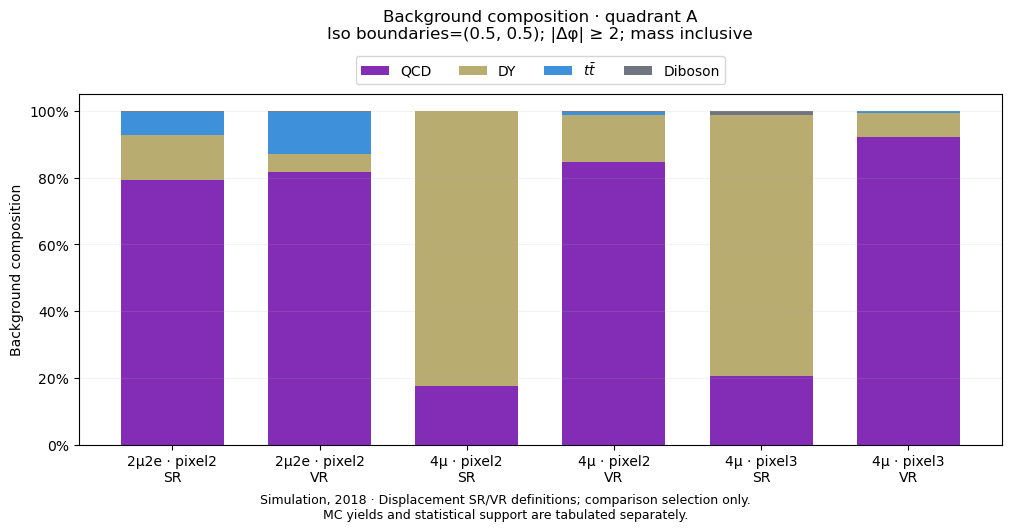

,channel,profile,context,QCD,DY,TTJets,Diboson,BKG,Neff
0,2mu2e,pixel2,SR,38.40 ± 14.83,6.50 ± 4.59,3.27 ± 3.27,0.21 ± 0.21,48.38 ± 15.87,9.29
1,2mu2e,pixel2,VR,2605.66 ± 828.40,169.21 ± 36.41,399.39 ± 36.16,12.70 ± 1.72,3186.96 ± 829.99,14.74
2,4mu,pixel2,SR,0.70 ± 0.66,3.25 ± 3.25,0.00 ± 0.00,0.00 ± 0.00,3.94 ± 3.31,1.42
3,4mu,pixel2,VR,1424.56 ± 376.84,237.11 ± 27.75,16.37 ± 7.32,3.20 ± 0.85,1681.24 ± 377.93,19.79
4,4mu,pixel3,SR,10.20 ± 7.45,38.98 ± 11.25,0.00 ± 0.00,0.60 ± 0.45,49.77 ± 13.50,13.59
5,4mu,pixel3,VR,1375.46 ± 376.40,107.19 ± 18.66,9.82 ± 5.67,1.40 ± 0.53,1493.87 ± 376.91,15.71


In [5]:
background_planes = load_background_planes()
background_regions, mc_comparisons = background_tables(background_planes)
plot_composition(background_regions)
composition_yields = background_regions.loc[
    np.isclose(background_regions.tx, COMPOSITION_WP[0]) &
    np.isclose(background_regions.ty, COMPOSITION_WP[1]) &
    background_regions.region.eq(COMPOSITION_REGION)].copy()
composition_summary = []
for (channel, profile, context), group in composition_yields.groupby(
        ["channel", "profile", "context"], sort=False):
    row = dict(channel=channel, profile=profile, context=context)
    for component in (*BACKGROUND_GROUPS, "BKG"):
        item = group.loc[group.group.eq(component)].iloc[0]
        row[component] = format_pm(item.yield_mc, item.error_mc, 2)
        if component == "BKG":
            row["Neff"] = round(item.neff, 2)
    composition_summary.append(row)
composition_summary = pd.DataFrame(composition_summary)
display(composition_summary)


## 7.2 Estimation method

\[
\widehat N_A=\frac{N_BN_C}{N_D},\qquad
\kappa=\frac{N_A}{\widehat N_A}.
\]

SR/VR의 displacement 정의와 ABCD의 isolation 사분면 정의는 별개다.
두 비교 WP는 최종 선택이 아니다. 1D scan의 반대쪽 경계 0.5는 event preselection이 아니다.
4μ pixel2 VR은 pixel3 SR과 겹치므로 두 profile을 동시에 독립적인 검증 영역으로 취급하지 않는다.
최종 네 영역 통계 모델과 신호 기여 처리는 AN 8장과 연결하되 이 노트북에서 fit이나 κ 보정을 수행하지 않는다.


,channel,profile,x_axis,y_axis,SR,VR,mass,abs_dphi,comparison_WP,fixed_1D_boundary
0,2mu2e,pixel2,mu-LJ isolation,eg-LJ isolation,mu max pixel <= 2; eg min lost >= 1,mu max pixel > 2; eg min lost < 1,inclusive,>= 2,"(0.25,0.25); (0.5,0.5)",0.5
1,4mu,pixel2,leading mu-LJ isolation,subleading mu-LJ isolation,both mu-LJ max pixel <= 2,both mu-LJ max pixel > 2,inclusive,>= 2,"(0.25,0.25); (0.5,0.5)",0.5
2,4mu,pixel3,leading mu-LJ isolation,subleading mu-LJ isolation,both mu-LJ max pixel <= 3,both mu-LJ max pixel > 3,inclusive,>= 2,"(0.25,0.25); (0.5,0.5)",0.5


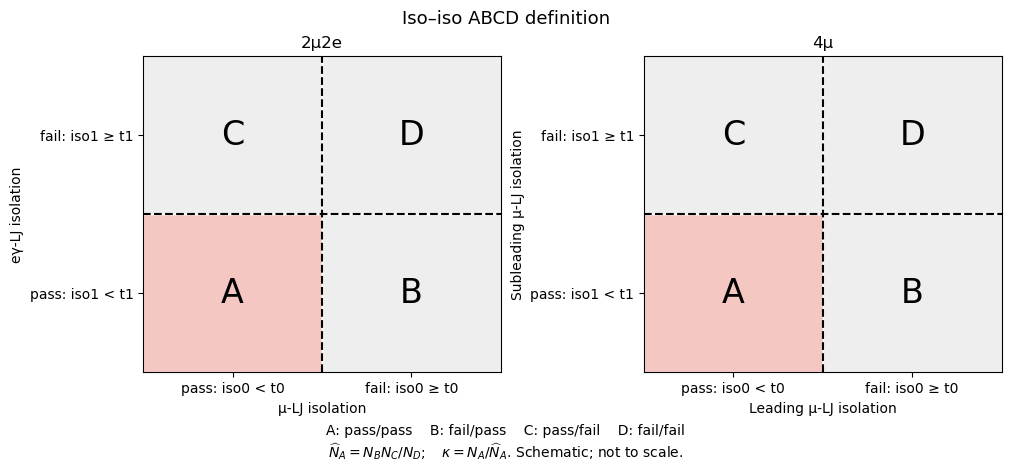

In [6]:
definitions = selection_table()
display(definitions)
plot_regions()


## 7.3 Validation

저장된 DATA 결과와 새로 계산한 MC 통계를 구분한다. DATA를 MC의 큰 오차로 평가하지 않는다.

- 2μ2e: loose 비교점은 유망하지만 다른 경계에서의 의존성을 함께 제시한다.
- 4μ: 비교 지점에서 뚜렷한 DATA nonclosure가 있으므로 검증 완료로 서술하지 않는다.
- MC SR: 작은 유효 통계 때문에 SR closure 입증에 한계가 있다.
- DATA 공개 정책·신호 정규화·보호 SR, 최종 mass selection으로의 연결은 미완료 항목이다.

기존 AN 8.9의 최종 selection과 여기의 6D mass-inclusive 결과는 서로 다른 스터디다.
현재 표의 SR/VR 표기는 displacement 선택이며, signal quadrant는 두 경우 모두 A이다.


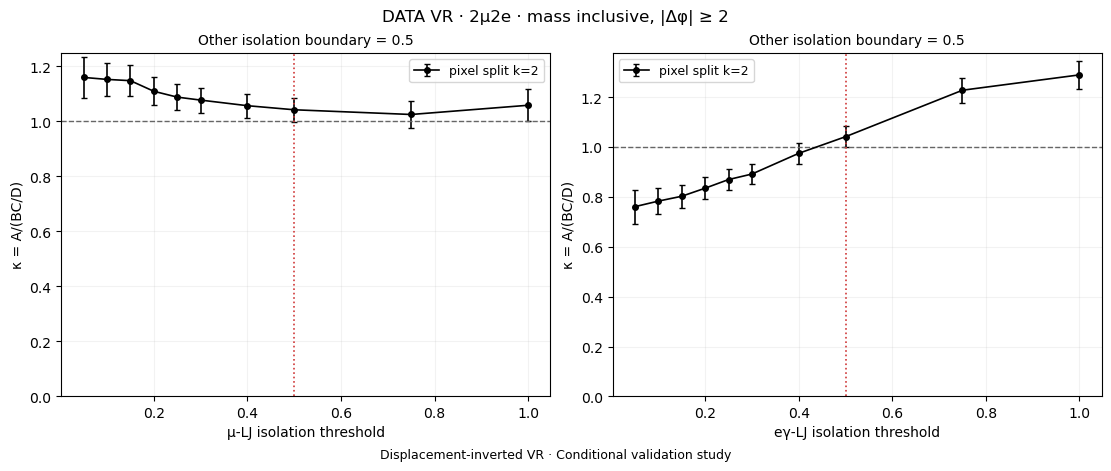

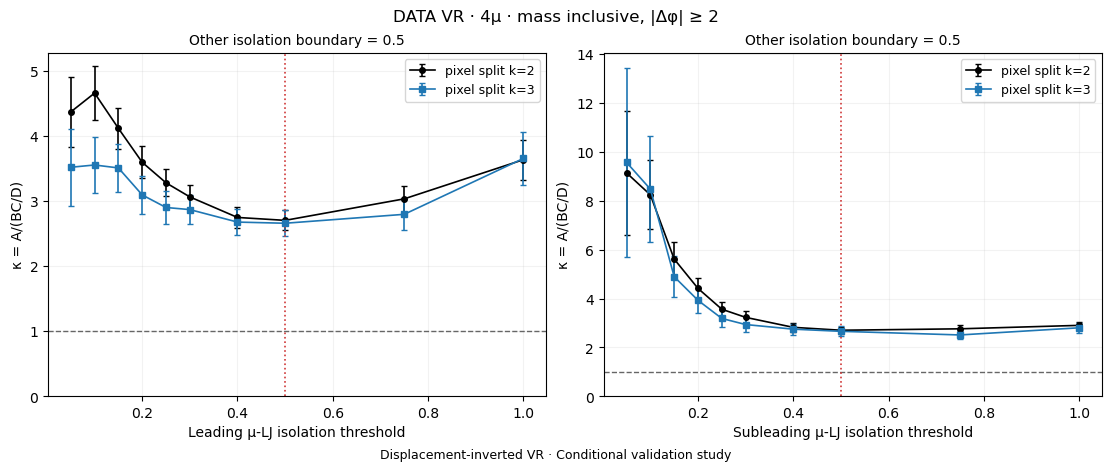

,channel,profile,tx,ty,DATA VR κ,MC SR min Neff,MC VR min Neff
0,2mu2e,pixel2,0.25,0.25,0.892 ± 0.047,2.25,4.00
1,2mu2e,pixel2,0.50,0.50,1.042 ± 0.043,1.31,14.74
2,4mu,pixel2,0.25,0.25,5.179 ± 0.414,1.00,7.65
3,4mu,pixel2,0.50,0.50,2.704 ± 0.152,1.05,8.30
4,4mu,pixel3,0.25,0.25,4.113 ± 0.448,6.14,6.36
5,4mu,pixel3,0.50,0.50,2.659 ± 0.198,2.07,6.10


In [7]:
data_scan, data_comparison = read_saved_data()
for channel in CHANNELS:
    plot_data_closure(data_scan, channel)
keys = ["channel", "profile", "tx", "ty"]
validation = data_comparison[keys+["data_VR_kappa", "data_VR_kappa_error",
    "legacy_gate_passed", "data_status"]].copy()
for context in ("SR", "VR"):
    selected = mc_comparisons.loc[mc_comparisons.context.eq(context),
        keys+["A", "A_error", "pred", "pred_error", "kappa", "kappa_error", "min_neff"]]
    validation = validation.merge(selected.rename(columns={c:f"mc_{context}_{c}" for c in selected if c not in keys}),
                                  on=keys, validate="one_to_one")
# MC 재투영과 기존 노트북 결과가 출력 정밀도 내에서 일치하는지 확인한다.
for context in ("SR", "VR"):
    for metric in ("kappa", "kappa_error", "min_neff"):
        column = f"mc_{context}_{metric}"
        if column in data_comparison:
            check = validation[keys+[column]].merge(data_comparison[keys+[column]], on=keys, suffixes=("_new","_saved"))
            np.testing.assert_allclose(check[column+"_new"], check[column+"_saved"], atol=6e-7, rtol=1e-6, equal_nan=True)
validation_summary = validation[keys].copy()
validation_summary["DATA VR κ"] = [format_pm(a,b) for a,b in zip(validation.data_VR_kappa, validation.data_VR_kappa_error)]
validation_summary["MC SR min Neff"] = validation.mc_SR_min_neff.round(2)
validation_summary["MC VR min Neff"] = validation.mc_VR_min_neff.round(2)
display(validation_summary)


## AN으로 옮길 산출물 저장

본문용 그림 네 장과 정의·composition·κ 요약표를 저장한다. 상세 수치는 CSV로 남긴다.
LaTeX 표는 booktabs 형식이다. caption은 captions.tex에 모으며 최종 그림 번호는 AN에서 붙인다.
manifest.json에 입력 AN·노트북의 hash, 배경 입력 경로와 설정을 남긴다.


In [8]:
if SAVE_OUTPUTS:
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    for path in SOURCE_PDFS:
        if path.is_file():
            record_source(path, "analysis_note_reference")
    tables = dict(definitions=definitions, composition_summary=composition_summary,
        composition_yields=composition_yields, background_regions=background_regions,
        mc_comparisons=mc_comparisons, validation=validation,
        validation_summary=validation_summary, saved_data_scan=data_scan)
    for name, frame in tables.items():
        frame.to_csv(RUN_DIR / f"{name}.csv", index=False)
    # Export readable LaTeX without relying on Unicode math support in the AN compiler.
    latex_definitions = definitions[["channel","profile","x_axis","y_axis","SR","VR"]]
    latex_composition = composition_summary.copy()
    latex_validation = validation_summary.rename(columns={"DATA VR κ": "DATA VR kappa"})
    for name, frame in (("definitions", latex_definitions), ("composition", latex_composition),
                        ("validation", latex_validation)):
        text = frame.to_latex(index=False, escape=True)
        text = text.replace("±", r"$\pm$")
        for operator, replacement in (("<=", r"$\leq$"), (">=", r"$\geq$"),
                                      (" < ", r" $<$ "), (" > ", r" $>$ ")):
            text = text.replace(operator, replacement)
        if name in {"definitions", "composition"}:
            text = "\\resizebox{\\textwidth}{!}{%\n" + text + "}\n"
        (RUN_DIR / f"table_7_{name}.tex").write_text(text)
    captions = "\n\n".join("% "+name+"\n% "+caption for name,caption in FIGURE_CAPTIONS.items())
    (RUN_DIR / "captions.tex").write_text(captions+"\n")
    manifest = dict(campaign=CAMPAIGN, channels=CHANNELS, mass_min=None, dphi_min=2,
        composition_region=COMPOSITION_REGION, composition_wp=COMPOSITION_WP,
        comparison_wps=COMPARISON_WPS, fixed_scan_boundary=.5, scan_display_max=AN_SCAN_MAX,
        data_source="saved 01/02 HTML tables; displayed precision",
        data_status="conditional diagnostic; signal normalization and release policy pending",
        raw_data_read=False, source_records=SOURCE_RECORDS, figures=FIGURE_CAPTIONS)
    (RUN_DIR / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2))
    print("AN 산출물:", RUN_DIR)


AN 산출물: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_plane_summary/04_AN_background_estimation_outputs/20261006T114019002274Z
